# Training Configurations Analysis

This notebook compares the training behavior of the four waste classification experiments:

#### baseline, synthetic_augmented, augmentation, synthetic





In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Automatically fix paths when this notebook is inside the notebooks/ folder
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = RESULTS_DIR / "models"
CURVES_DIR = RESULTS_DIR / "loss_curves"


print("Results dir exists:", RESULTS_DIR.exists())
print("Models dir exists:", MODELS_DIR.exists())
print("Curves dir exists:", CURVES_DIR.exists())


## 1. Define experiment configs

In [15]:
configs = ["baseline", "augmentation", "synthetic", "synthetic_augmented"]

config_descriptions = {
    "baseline": "Real training images only, no augmentation.",
    "augmentation": "Real training images with random augmentation.",
    "synthetic": "Real training images plus synthetic generated variants.",
    "synthetic_augmented": "Real + synthetic images with augmentation."
}

pd.DataFrame({
    "config": configs,
    "description": [config_descriptions[c] for c in configs]
})


,config,description
0,baseline,"Real training images only, no augmentation."
1,augmentation,Real training images with random augmentation.
2,synthetic,Real training images plus synthetic generated ...
3,synthetic_augmented,Real + synthetic images with augmentation.


## 2. Training history files

Each training run saves a file like:

```text
results/baseline_history.json
results/augmentation_history.json
results/synthetic_history.json
results/synthetic_augmented_history.json
```


## 3. Training summary table

In [4]:
summary_rows = []

for cfg, h in histories.items():
    best_val_acc = max(h["val_acc"])
    best_epoch = h["val_acc"].index(best_val_acc) + 1

    summary_rows.append({
        "config": cfg,
        "description": config_descriptions[cfg],
        "best_val_acc": round(best_val_acc, 4),
        "best_epoch": best_epoch,
        "final_train_acc": round(h["train_acc"][-1], 4),
        "final_val_acc": round(h["val_acc"][-1], 4),
        "final_train_loss": round(h["train_loss"][-1], 4),
        "final_val_loss": round(h["val_loss"][-1], 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("best_val_acc", ascending=False)
summary_df


,config,description,best_val_acc,best_epoch,final_train_acc,final_val_acc,final_train_loss,final_val_loss
3,synthetic_augmented,Real + synthetic images with augmentation.,0.8000,9,0.7107,0.7500,0.9878,0.9893
2,synthetic,Real training images plus synthetic generated ...,0.7667,9,0.7571,0.7667,0.9524,0.9668
0,baseline,"Real training images only, no augmentation.",0.7167,8,0.7036,0.6167,1.1043,1.1235
1,augmentation,Real training images with random augmentation.,0.6500,9,0.6714,0.6500,1.1231,1.1218


## 4. Validation accuracy comparison

This plot shows how validation accuracy changes over epochs for each experiment.


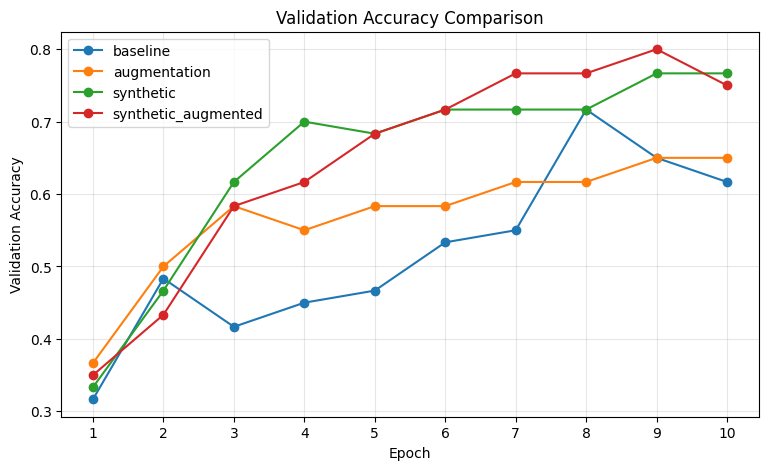

In [5]:
plt.figure(figsize=(9, 5))

for cfg, h in histories.items():
    epochs = range(1, len(h["val_acc"]) + 1)
    plt.plot(epochs, h["val_acc"], marker="o", label=cfg)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Training accuracy comparison

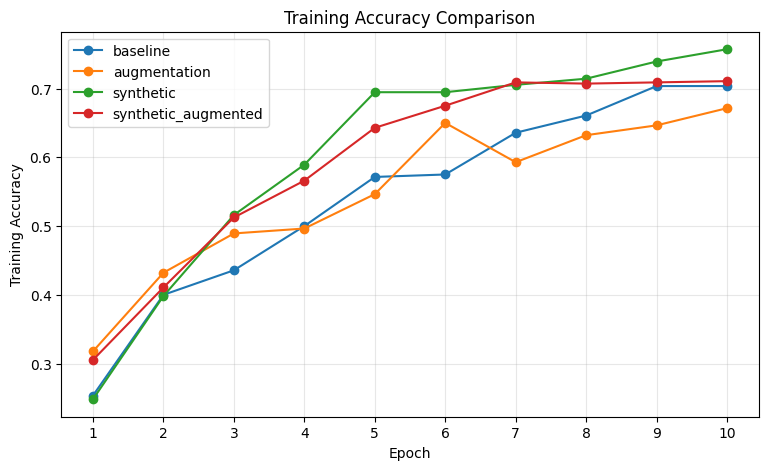

In [6]:
plt.figure(figsize=(9, 5))

for cfg, h in histories.items():
    epochs = range(1, len(h["train_acc"]) + 1)
    plt.plot(epochs, h["train_acc"], marker="o", label=cfg)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Validation loss comparison

Lower validation loss usually means better generalization


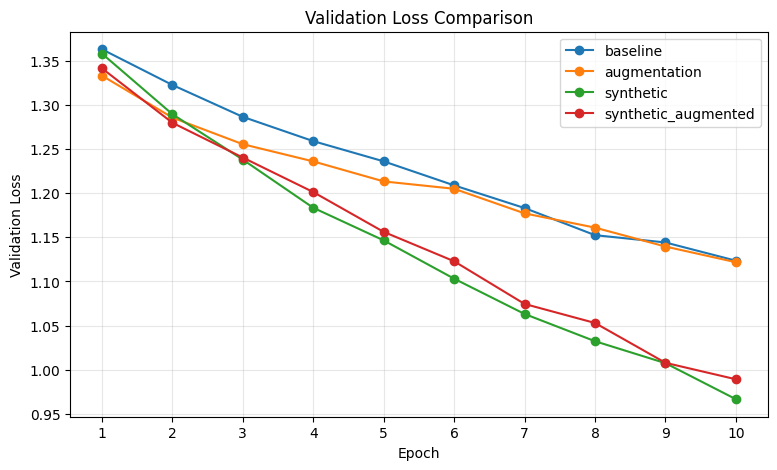

In [7]:
plt.figure(figsize=(9, 5))

for cfg, h in histories.items():
    epochs = range(1, len(h["val_loss"]) + 1)
    plt.plot(epochs, h["val_loss"], marker="o", label=cfg)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Training loss comparison

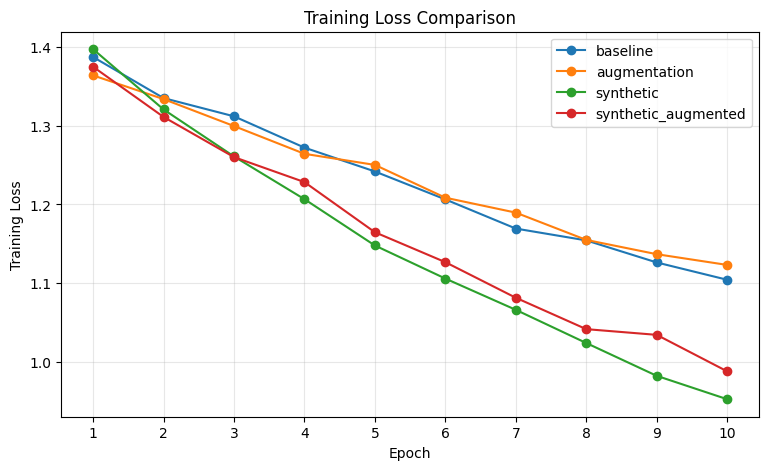

In [8]:
plt.figure(figsize=(9, 5))

for cfg, h in histories.items():
    epochs = range(1, len(h["train_loss"]) + 1)
    plt.plot(epochs, h["train_loss"], marker="o", label=cfg)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Model checkpoints

Each config should have a saved checkpoint:

```text
results/models/<config>_best.pth
```


In [18]:
checkpoint_rows = []

for cfg in configs:
    ckpt_path = MODELS_DIR / f"{cfg}_best.pth"
    checkpoint_rows.append({
        "config": cfg,
        "checkpoint_exists": ckpt_path.exists(),
        
    })

checkpoint_df = pd.DataFrame(checkpoint_rows)
checkpoint_df


,config,checkpoint_exists
0,baseline,True
1,augmentation,True
2,synthetic,True
3,synthetic_augmented,True


## 9. Test Final results combined


In [12]:
# Replace values with your actual results.
# Leave as None if you have not evaluated that config yet.

test_accuracies = {
    "baseline": 0.6167,
    "augmentation": 0.6667,
    "synthetic": 0.7333,
    "synthetic_augmented": 0.6833,
}

test_df = pd.DataFrame([
    {"config": cfg, "test_accuracy": acc}
    for cfg, acc in test_accuracies.items()
])

combined_df = summary_df.merge(test_df, on="config", how="left")
combined_df


,config,description,best_val_acc,best_epoch,final_train_acc,final_val_acc,final_train_loss,final_val_loss,test_accuracy
0,synthetic_augmented,Real + synthetic images with augmentation.,0.8000,9,0.7107,0.7500,0.9878,0.9893,0.6833
1,synthetic,Real training images plus synthetic generated ...,0.7667,9,0.7571,0.7667,0.9524,0.9668,0.7333
2,baseline,"Real training images only, no augmentation.",0.7167,8,0.7036,0.6167,1.1043,1.1235,0.6167
3,augmentation,Real training images with random augmentation.,0.6500,9,0.6714,0.6500,1.1231,1.1218,0.6667


## 10. Test accuracy comparison

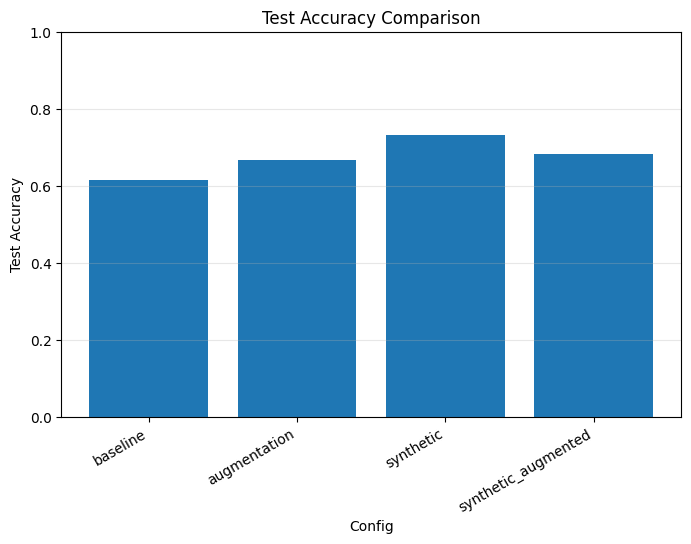

In [13]:
plot_test_df = test_df.dropna()

if len(plot_test_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.bar(plot_test_df["config"], plot_test_df["test_accuracy"])
    plt.title("Test Accuracy Comparison")
    plt.xlabel("Config")
    plt.ylabel("Test Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
else:
    print("No test accuracies entered yet.")
